

**<font size="6">Risk Management Grundlagen</font>**
 
**Prof. Dr. Fabian Woebbeking**

<br/>

Assistant Professor of Financial Economics

fabian.woebbeking@dozent.frankfurt-school.de


<br/><br/><br/><br/>

![logo.png](figures/logo.png)

<a id='Einleitung'></a>

# Einleitung

Bücher:

- Heidorn, Schäffler: Finanzmathematik in der Bankpraxis
- Hull: Options, Futures and other Derivatives
- Jarrow, Chatterjea: Derivative Securities, Financial Markets, and Risk Management

Filme:

- The Big Short, 2015
- Margin Call, 2011

Materialien:

- Handout
- Codes sollen Berechnungen nachvollziehbar machen (Kein IT Kurs!), z.B. ...

In [39]:
ergebnis = 2 + 2 * 2
print(f'Ergebnis = {ergebnis:.2f}')

Ergebnis = 6.00


Agenda:

1. Einleitung / Finanzmathematische Grundlagen

2. Risikoübersicht und Derivate

3. Zinsmanagement und Zinsderivate

4. Währungsmanagement und FX Derivate

In [40]:
# imports (ignore this box):
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Some pre formatting for the matplots
plt.rcParams.update({'font.size': 14,
                     'figure.figsize':  (21/2,9/2)
                    })

## Zinsen (Usancen / 'Sprachen')

In der Finanzwelt sind Zinsusancen entscheidende Konventionen, die bestimmen, wie Zinsen für verschiedene Finanzinstrumente berechnet und angegeben werden. Diese Konventionen sind für das Verständnis und die Durchführung finanzieller Transaktionen von grundlegender Bedeutung, da sie die Basis für die Berechnung der Rendite von Investitionen bilden. Die folgende Einführung soll einen umfassenden Überblick über die gängigen Zinsusancen geben, ihre Anwendung in der Praxis erläutern und ihre Bedeutung im Kontext des globalen Finanzsystems verdeutlichen.



Quotieren per annum (p.a.) in verschiedenen Sprachen:

Geldmarkt / Money Market (MM): 

$$C_0(1+r_{mm}t)=C_t$$

Kapitalmarkt ISMA (International Securities Market Association - Europe)

$$C_0(1+r_{isma})^t=C_t$$

t ist die Anzahl der Tage einer Periode geteilt durch die Anzahl der Tage im Basisjahr, e.g.

$t = act/360$ (Money Markets - DE/US/...)

$t = act/act$ (Bond - ISMA)

$t = 30/360$ (Swap, fixed leg)


SIA (Securities Industry Association - US) wenn $m = 2$

$$C_0(1+r_{sia}/m)^{mt}=C_t$$

Kontinuierliche Verzinsung (academics, financial engineering)

$$C_0 e^{r_{cont}t} = C_t$$

In [41]:
"""Continous compounding
"""
def FV(m):
    C_0 = 1
    r  = 1
    t  = 1
    return C_0 * (1 + r / m)**(t * m)

#FV_m = list(map(lambda m: FV(m), range(1,250)))
FV_m = FV(np.arange(1,250))

# plotting
def plot_FV():
    plt.figure('exp')
    plt.title("Mit C_0 = 1, r = 100% und t = 1")
    plt.plot(FV_m)
    plt.axhline(y=np.exp(1), linewidth=1, color="red")
    plt.xlabel("m")
    plt.ylabel("FV in t")
    plt.show()


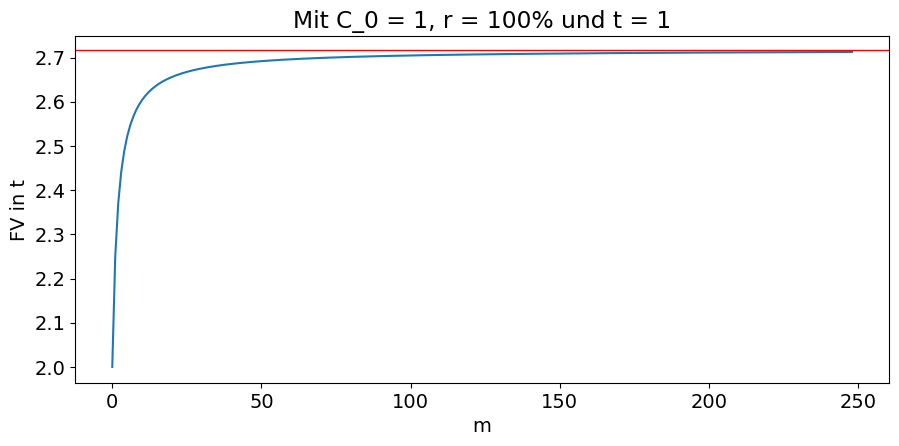

In [42]:
plot_FV()

In [43]:
print(f'FV(m = 100000) = {FV(100000):.4f}')
print(f'EXP(1)         = {np.exp(1):.4f}')

FV(m = 100000) = 2.7183
EXP(1)         = 2.7183


Cash ist unabhängig von der Zinssprache (i.e. $C_t = C_t$), daher lassen sich Zinssätze einfach umrechnen, z.B.:

$$
\begin{aligned}
C_0 e^{r_{cont}} &= C_0 (1+r_{isma})\\
r_{cont} &= \ln(1+r_{isma})
\end{aligned}
$$

In [44]:
"""Interest rate conversion (translation)
"""
import numpy as np

r_isma = 0.1
r_mm = (r_isma*360/365)
r_sia = ((1+r_isma)**0.5-1)*2
r_cont = np.log(1+r_isma)

print(f'r_isma  = {r_isma:.4f}')
print(f'r_mm    = {r_mm:.4f}')
print(f'r_sia   = {r_sia:.4f}')
print(f'r_cont  = {r_cont:.4f}')

r_isma  = 0.1000
r_mm    = 0.0986
r_sia   = 0.0976
r_cont  = 0.0953


## Discount factor (Barwertfaktor / Abzinsungsfaktor)

Unter ISMA Verzinsung

$$C_0 = C_t \times \frac{1}{(1+r_t)^t} = C_t \times B_t$$

Discount Factor $B_t$ (Zero **B**ond).

$$B_t = \frac{1}{(1+r_t)^t} = \frac{C_0}{C_t}$$

In [45]:
def pv(t, C_t, r_t):
    return C_t / (1 + r_t) ** t

def df(t, r_t):
    return 1 / (1+r_t)**t

print(f'pv(1, 110, 0.1)  = {pv(1, 110, 0.1):.2f}')
print(f'110 * df(1, 0.1) = {110 * df(1, 0.1):.2f}')

pv(1, 110, 0.1)  = 100.00
110 * df(1, 0.1) = 100.00


## Discounted cash flow

$$P = \sum^T_{t=1} C_t \times \frac{1}{(1+r_t)^t} = \sum^T_{t=1} C_t \times B_t$$

In [46]:
def dcf(cash_flows):
    P = 0
    for t, C_t, r in cash_flows:
        P += pv(t, C_t, r)
    return P

cash_flows = [(1, 10, 0.1), (2, 10, 0.1), (3, 110, 0.1)]
print(f'cash_flows = {cash_flows}')
print(f'dcf(cash_flows) = { dcf(cash_flows) :.2f}')

cash_flows = [(1, 10, 0.1), (2, 10, 0.1), (3, 110, 0.1)]
dcf(cash_flows) = 100.00


## Rendite

### Zero/spot rate

$$r_t = \left( \frac{C_t}{C_0} \right) ^{1/t}- 1 = \left( \frac{1}{B_t} \right) ^{1/t} - 1$$

### Internal rate of return (IRR)

Die IRR löst folgende Gleichung:

$$0 = C_0 + \sum^T_{t=1} C_t \times \frac{1}{(1+r)^t}$$

Sofern es nur einen zukünftigen Cash Flow gibt, ist die IRR gleich der Spot Rate.

Zinsen Mini-Case, folgender Markt an Zero Bonds ist gegeben:

* 1Y: 90,91
* 2Y: 81,16
* 3Y: 71,18

1. Was ist der Marktwert eines 6% Bonds mit 3 Jahren Laufzeit?
2. Wie verändert sich die IRR wenn ein höherer Coupon (12%) emittiert wird?


In [47]:
"""Coupon (nominal yield) vs yield to maturity
"""
from scipy.optimize import minimize
import matplotlib.pyplot as plt

discount_factors = [.9091, .8116, .7118]  # (normal term structure)

zero_rates = []
for T, DF_T in enumerate(discount_factors):
    T = T + 1
    r_T = (1 / DF_T) ** (1 / T) - 1
    zero_rates.append(r_T)
print(zero_rates)


# face value = 1!
def IRR(coupon, discount_factors):
    # calculate PV from market prices
    def fair_price(coupon):
        p = coupon * sum(discount_factors) + discount_factors[-1]
        return p
    # calculate PV from irr
    def IRR_price(irr, coupon):
        T = len(discount_factors)
        annuity_factor = (1 - (1 + irr) ** -T) / irr
        p = coupon * annuity_factor + 1 / (1 + irr) ** T
        return p
    # target function to be minimized
    def NPV2(irr):
        return (fair_price(coupon) - IRR_price(irr, coupon)) ** 2
    # set NPV = 0 and return both PVs and the irr
    opt = minimize(NPV2, x0=0.01, bounds = ((None, None),))
    return [fair_price(coupon), IRR_price(opt.x[0], coupon), opt.x[0]]


#print(IRR(.1, discount_factors))

def plot_irr_cpn():
    # lets plot different coupon rates against irrs
    x_coupons = range(100)
    y_irrs = list(map(lambda c: IRR(c/100, discount_factors)[2]*100, x_coupons))

    plt.figure('irr_cpn')
    plt.plot(x_coupons, y_irrs)
    plt.axhline(y=zero_rates[-1]*100, linestyle='--', linewidth=1, color='grey')
    plt.xlabel("Coupon rate in %")
    plt.ylabel("YTM (IRR) in %")
    plt.show()

[0.09998900010999878, 0.11001534051800954, 0.11998964004232815]


Die IRR / Yield to Maturity (YTM) eines Bonds ist ein gewichteter Durschnitt der Spot Renditen. Daher:

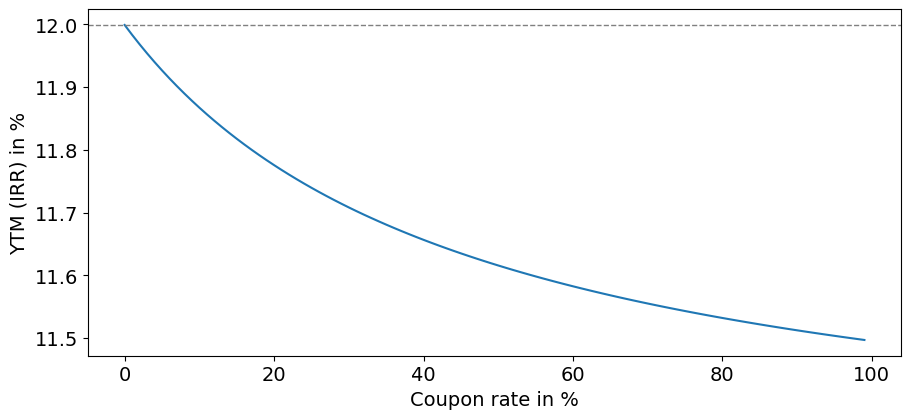

In [48]:
plot_irr_cpn()

## Referenzzinsen

- Was sind Referenzzinsen?
- Wofür benötigen wir Referenzzinsen?

Für den Eurogeldmarkt in London wurde ein sogenannter Referenzsatz oder eine Benchmark-Rate eingeführt. Das ist der **London Interbank Offered Rate (LIBOR)**. 

Der LIBOR ist ein international anerkannter Referenzsatz, der sich aus der Stellung des Londoner Bankplatzes und seiner Wichtigkeit im Geldmarkt (EUR-/USD-markt) entwickelt hat.

LIBOR-Sätze werden für Perioden zwischen O/N und 12 Monaten täglich um 11 Uhr London Zeit von der British Bankers' Association (BBA) veröffentlicht und haben sich zum Referenzsatz für viele Arten von Geschäften entwickelt (wie z. B. zum Fixing von FRAs, Interest-Rate-Swaps oder Krediten etc.).

Interbanksätze werden aber auch in anderen größeren Finanzzentren der Welt quotiert, wobei mit der Einführung des Euro viele Sätze obsolet wurden (z.B. FIBOR, BIBOR, VIBOR). Der **EURIBOR** (Euro Interbank Offered Rate) ersetzt diese nationalen Interbanksätze. Dabei handelt es sich um einen, um Extremwerte (obere und untere (z.Z 4) Quotierungen werden eliminiert) bereinigten, Durchschnitt von Briefsätzen. Täglich melden 26 Kreditinstitute ihre Offerten, an die sie jedoch nicht gebunden sind. Der EURIBOR wird auf 3 Nachkommastellen quotiert.

Euribor

![image.png](figures/euribor.png)

### LIBOR Skandal

![image.png](figures/usdinterbankfines.png)

Transaktionsbasierte Referenzzinsen

Das **Eonia-Fixing (Euro Overnight Index Average)** ist der gewichtete Durchschnitt aller Interbank Tagesgeldtransaktionen im Euroraum. Es quotieren die gleichen 26 Banken wie beim Euribor-Fixing. Die Zinsmethode ist Act/360. Das Fixing wird von der EZB zwischen 18:45 Uhr 19:00 Uhr auf 3 Nachkommastellen ermittelt.

Aktueller Stand: tägliche Bereitstellung von **€STR** ab 10/2019. Die EZB verwendet die Daten der Geldmarktstatistik (MMSR) 52 Banken davon 14 deutsche Banken.

EURIBOR should also be non-compliant under the Benchmark Regulation (BMR), an **€STR-term** will be created to replace EURIBOR.

![image.png](figures/estr.png)

<a id='Risikoübersicht'></a>

# Risikoübersicht

Was verstehen Sie unter Risiko?

Wir unterscheiden

- **Marktrisiko / market risk**: Ungewissheit über Martpreise, z.B. Aktien, FX, Bonds, Zinsen, Rohstoffe, ...
- **Liquiditätsrisiko / liquidity risk**
    - Firmenliquidität: Die Fähigkeit jederzeit  alle Zahlungen leisten zu können. 
    - Produktliquidität: Ein Produkt in großen Volumina jederzeit bei einer engen Geld-Brief-Spanne handeln zu können, ohne den Preis zu bewegen.
- **Kreditrisiko / credit risk**: Ungewissheit über die Erfüllung Vertraglicher Verpflichtungen.
- Operational Risk
- Model Risk
- Legal Risk


Beispiel Zinsrisiko:

Die Veränderung von Zinsen kann sich auf verschiedene Weisen auswirken:
- Links: PV Risiko (Marktwertrisiko) 
- Rechts: Cash Flow Risiko (Ertragsrisiko)

![image-3.png](figures/festfloatrisiko.png)

In [49]:
def annuity_factor(r, T):
    return (1 - (1 / (1 + r)**T ) ) / r

def pv_fix(r, T=5, Cpn=0.03):
    return annuity_factor(r, T) * Cpn + 1 / (1 + r) ** T

def pv_float(r, T=5):
    return (1 - 1 / (1 + r) ** T) + 1 / (1 + r) ** T

def plot_rrisk():
    rates = np.linspace(-0.05,0.2,25)
    plt.figure('rrisk')
    plt.plot(rates*100, pv_fix(rates)*100, label="Festsatzanleihe 3% 5Y")
    plt.plot(rates*100, pv_float(rates)*100, label="Floater 5Y")
    plt.xlabel("Zins in %")
    plt.ylabel("Barwert in %")
    plt.legend()
    plt.show()

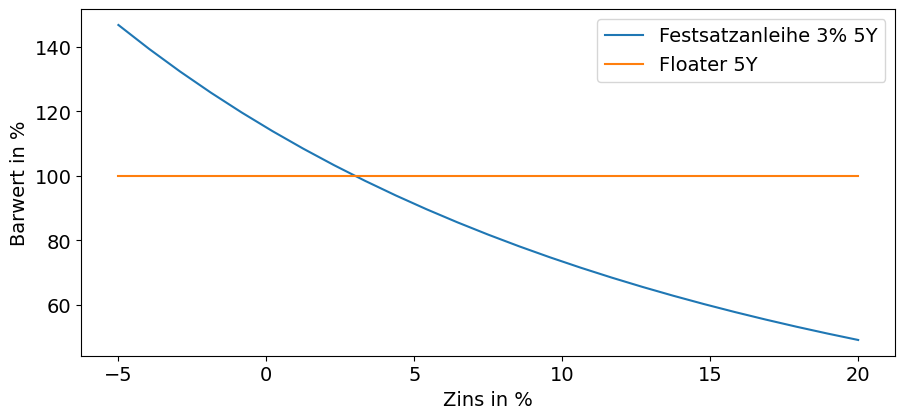

In [50]:
plot_rrisk()

Dies ist eine vereinfachende Darstellung ... welche weiteren Faktoren wirken auf den Barwert des Floaters?

## Trennung Zins/Liquidität!

Zinsrisiko ist ein klassisches **Marktrisiko** und kann über Zinsswaps gesteuert werden (klassische Treasury)
Verbleibende Risiken müssen mit Eigenkapital unterlegt werden

Liquiditätsrisiken sind Strukturrisiken, keine Eigenkapitalrisiken

Steuerung durch: 

- Unbesicherte  Mittelaufnahme  
- Besicherte  Mittelaufnahme 
- Veräußerung von Aktiva

Liquiditätsrisiken können zur Zeit kaum abgesichert werden. 


## Risiko bedeutet Ungewissheit

Zufallsvariable $X \sim \mathcal{N}(\mu,\sigma^2)$ als Beispiel einer stetigen Wahrscheinlichkeitsverteilung.

Probability density function (PDF):
$$\phi(x) = \frac{d\Phi(x)}{dx} = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{x-\mu}{\sigma} \right)^2 }$$


Cumulative distribution function (CDF):
$$\Phi(x) = P(X \le x) = \int_{-\infty}^x \phi(u)\; du$$

Quantile function, i.e. inverse of the CDF:
$$\Phi^{-1}(p) = \inf \{x \in \mathbb{R}: p \le \Phi(x)\},\;\; p \in (0,1)$$

In [51]:
"""PDF vs CDF
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, t, skewnorm

x = np.linspace(-7, 7, 100)
p = np.linspace(0, 1)

def plot_pdf():
    plt.figure("pdf")
    # Left
    plt.subplot(1, 2, 1)
    plt.title("Probability Density Function (PDF)")
    plt.plot(x, norm.pdf(x, 0, (5*np.sqrt(5/3))/3), label='Normal')
    plt.plot(x, t.pdf(x, 3, 0, 5/3), label='Heavy tailed')
    plt.axvline(x=-5, color='red', linewidth=.75)
    plt.axvline(x=0, color='grey', linewidth=.75)
    plt.legend(loc='upper right')
    plt.xticks([])
    plt.yticks([])
    # Right
    plt.subplot(1, 2, 2)
    plt.plot(x, norm.pdf(x, 0, (5*np.sqrt(5/3))/3), label='Marktrisiko')
    plt.plot(x, skewnorm.pdf(x, -6, 4, 5/3*3), label='Kreditrisiko')
    plt.axvline(x=0, color='grey', linewidth=.75)
    plt.legend(loc='upper left')
    plt.xticks([])
    plt.yticks([])
    plt.show()

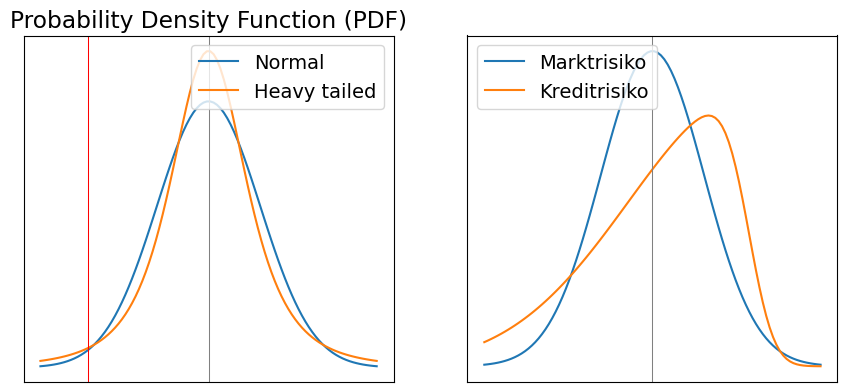

In [52]:
plot_pdf()

# Derivate zur Risikosteuerung

Was ist ein Derivat? 

Abgeleitetes Finanzprodukt. Wert hängt von der Entwicklung eines anderen Gegenstandes (Underlying) ab. Anders als bei traditionellen Assets gilt:

- Volumen beliebig
- Nullsummenspiel
- Preis = Hedgekosten

Unterscheidung nach Cash Flow:

- Symmetrische Derivate: z.B. Forward, Future, Swap
- Asymmetrische Derivate: Optionen
- Kreditderivate: z.B. Credit Default Swap

Unterscheidung nach Underlying:

- Zinsen: Swap, Forward Rate Agreement, Cap, Floor, Swaption
- Währungen: Forward, FX Swap, FX Option
- ...

**Admiral van der Eijk**

- Netherlands 1633 bis 1637
- January 1937, Preis 5200 Gulden
- (Jahresgehalt Dachdecker 250 Gulden)
- (Jahresgehalt Professor 750 Gulden)
- (Glas Bier 1/40 Gulden)

![image.png](figures/AdmiralVanDerEijk.jpg)

Diskussion: "Teufelszeug aka Weapons of Mass Destruction"

- Derivate sind überflüssig, weil nur umverteilt wird (Nullsummenspiel)!?
- Spekulation hat keinen volkswirtschaftlichen Nutzen!?
- Derivate sind finanzielle Massenvernichtungswaffen!?


![image.png](figures/derivativesdept.png)

## Kontrahentenrisiko (Credit Risk)

Derivate sind immer Termingeschäfte, daher werden Zahlungen in der Zukunft geleistet. Die Höhe der Zahlung ist ungewiss, i.e. klassisches **Marktrisiko**. Die Zahlung selbst ist ebenfalls ungewiss, i.e. **Kontrahentenrisiko**. Siehe [Canabarro und Duffy: "Measuring and marking counterparty risk"](https://web.stanford.edu/~duffie/Chapter_09.pdf)


In [53]:
def plot_ppe():
    # Defining the range for the x values (encompassing most of the significant probability mass of the distribution)
    x = np.linspace(-4, 4, 1000)
    pdf = norm.pdf(x)

    # Calculate the PPE
    quantile_95 = norm.ppf(0.95)

    # Calculate the EPE
    expected_positive = norm.expect(lambda x: x, lb=0, ub=np.inf)

    # Plotting
    plt.figure("ppe")
    plt.plot(x, pdf, color='black')
    plt.fill_between(x, pdf, where=(x > 0), color='steelblue', alpha=0.5, label='Positive exposure')
    plt.axvline(x=expected_positive, color='green', linestyle='--', label='Expected Positive Exposure (EPE, auch EE)')
    plt.axvline(x=quantile_95, color='red', linestyle='--', label='Potential Positive Exposure (95%)')
    plt.title('Mark to Market Value')
    plt.xlabel('Value')
    plt.ylabel('Probability Density')
    plt.legend(loc='upper left')
    plt.show()


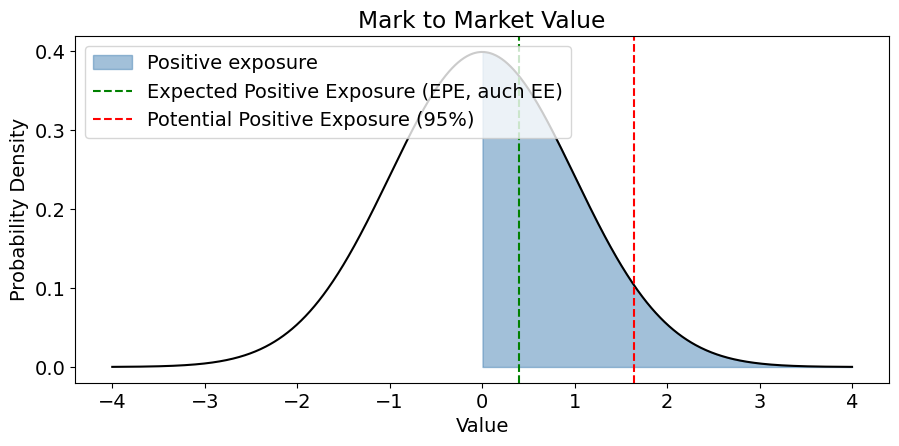

In [54]:
plot_ppe()

**Deutscher Rahmenvertrag (DRV):**

- Rahmenvertrag für Finanztermingeschäfte
- enthält für alle Einzelgeschäfte geltende rechtliche Bestimmungen Entlastung von Einzelabschlüssen durch Vorwegnahme von Bestimmungen und Abschlussmodalitäten
- verbindet alle Einzelabschlüsse, die sich auf den Rahmenvertrag beziehen, zu einem einheitlichen Vertrag
    - Verminderung des Insolvenzrisikos, indem im Insolvenzfall alle Einzelgeschäfte in eine einheitliche Ausgleichsforderung umgewandelt werden („Liquidationsnetting“)
    - Verhinderung des „right of cherry picking“
    - vertragliche Saldierung der Einzelgeschäfte vor Eröffnung eines Insolvenzverfahrens gem. §103 ff. InsO

**International Swaps and Derivates Association Master Agreement (ISDA MA):**

- Wird von deutschen Parteien meist bei grenzüberschreitenden Geschäften verwendet
- Viel detailliertere Regelung als der DRV; so sind im Anhang eine Vielzahl von Wahlmöglichkeiten und Definitionen enthalten
- Wird idR englischem Recht oder dem Recht des Staates NY unterstellt, kann aber auch anderen Rechtsordnungen unterstellt werden


**ISDA Credit Support Annex:**

* Leistung von Sicherheiten durch Vollrechtsübertragung (title transfer)
* Die sicherheitsleistende Partei überträgt der berechtigten Partei sämtliche Eigentumsrechte an den vereinbarten Sicherheiten und erhält dafür den schuldrechtlichen Anspruch auf Rückübertragung gleichwertiger Vermögensgegenstände sobald die besicherte Forderung erfüllt wurde 

**Central Counterparty (CCP) Clearing:**

![image.png](figures/clearing.png)

Der Austausch von Sicherheiten im Clearing wird auch Margining genannt, insbesondere sind zu unterscheiden:

* Variation Margin
* Initial Margin


![image.png](figures/clearingmember.png)

## Arbitrage

- Was ist Arbitrage?

- Was hat Arbitrage mit Derivaten zu tun?

**No-Arbitrage-Bedingung:** 

Dauerhaft darf es nicht möglich sein, einen risikolosen Gewinn durch den Kauf und Verkauf von Vermögensgegenständen auf einem Markt zu realisieren, da sich die Preise irgendwann angleichen werden.

Derivate werden immer unter einer No-Arbitrage-Bedingung bewertet.

1997 Nobelpreis für Wirtschaftswissenschaften: Black, Fischer, and Myron Scholes. "The Pricing of Options and Corporate Liabilities." The Journal of Political Economy 81.3 (1973): 637-654.

Derivatemärkte

![image.png](figures/otcnotionals.png)


<a id='Zinsmanagement'></a>

# Zinsmanagement und Zinsderivate

Welche Werkzeuge stehen zur Verfügung?



Zinsübersicht

![image.png](figures/ratesoverview.png)


## Zinsswap

Usancen:

- Zinstauschvereinbarung
- Nominal wird nicht getauscht
- Festsatzseite Kapitalmarkt (30/360)
- Variable Seite Geldmarkt (act/360)
- Volumen ab 5 Mio. Euro
- Laufzeit: 1 - 50 Jahre 
- Referenzzinssatz:	Euribor, Libor
- In der Praxis: meist gegen 6m Euribor



Typen:

- Plain-vanilla / Kupon-Swap (auch Festzinsswap genannt) Kapitalmarkt!: Austausch von einem fixen gegen einen variablen Zinssatz
- Overnight Index Swap (OIS) Geldmarkt!: Austausch von einem fixen gegen einen auf täglicher Basis variablem Zinssatz (z.B. Eonia)
- Basis-Swap: Austausch von zwei unterschiedlichen, variablen Zinssätzen in einer Währung
- Cross Currency Swap Austausch von zwei Zinssätzen in unterschiedlichen Währungen

Ein Zinsswap ist ein Vertrag zwischen zwei Parteien über den Austausch von unterschiedlichen, spezifizierten Zinszahlungen in einer Währung während eines im Vertrag fixierten Zeitraums. 

Die Höhe der Zinszahlung errechnet sich aus dem der jeweiligen Zinsperiode zugrundeliegenden Zinssatz und Kapitalbetrag, "Notional Amount"  genannt. Der Notional Amount wird beim Zinsswap nicht ausgetauscht.

![image.png](figures/swapquote2.png)



![image.png](figures/swap.png)

Liability swap:

![image.png](figures/liabilityswap.png)

Asset Swap:

![image.png](figures/assetswap.png)

Zur Bewertung von Swaps benötigen wir:

- Zero Rate

$$r_t = \left( \frac{C_t}{P} \right) ^{1/t}- 1 = \left( \frac{1}{B_t} \right) ^{1/t} - 1$$


- Forward rate

$$r_{st} = \left(\frac{(1+r_t)^t}{(1+r_s)^s}\right)^{1/(t-s)}-1 = \left(\frac{B_s}{B_t}\right)^{1/(t-s)}-1$$

In [55]:
def r_t(t, B_t):
    return (1 / B_t) ** (1 / t) - 1

def r_st(s, t, r_s, r_t):
    B_s = 1 / (1 + r_s) ** s
    B_t = 1 / (1 + r_t) ** t
    return (B_s / B_t) ** (1 / (t - s)) - 1

In [56]:
print(f'r_2  = r_t(2, 0.8116)       = { r_t(2, 0.8116)*100 :.2f}%')
print(f'r_3  = r_t(3, 0.7118)       = { r_t(3, 0.7118)*100 :.2f}%')
print(f'r_23 = r_st(2, 3, r_2, r_3) = { r_st(2, 3, r_t(2, 0.8116), r_t(3, 0.7118))*100 :.2f}%')

r_2  = r_t(2, 0.8116)       = 11.00%
r_3  = r_t(3, 0.7118)       = 12.00%
r_23 = r_st(2, 3, r_2, r_3) = 14.02%


## Plain vanilla swap pricing

Fix ($C$) gegen variable ($L_t$) Zahlung, e.g. LIBOR / EURIBOR. (Jährliche Zahlungen):

$$\begin{aligned}
P(\mathrm{Fix}) &= C \sum_{t=1}^T B_t\\
P(\mathrm{Var}) &= \sum_{t=1}^T L_t B_t\\
        &= \sum_{t=1}^T \left(\frac{B_{t-1}}{B_t} -1  \right) B_t\\
        &= 1 - B_T
\end{aligned}$$

$C$ ist fair wenn

$$\begin{aligned}
P(\mathrm{Fix}) &= P(\mathrm{Var})\\
C \sum_{t=1}^T B_t &= 1 - B_T\\
C        &= \frac{1 - B_T}{\sum_{t=1}^T B_t}
\end{aligned}$$

In [57]:
def C_swap(discount_factors):
    return (1 - discount_factors[-1]) / sum(discount_factors)

# this is the example from your ppt Slide 156
print(f'C_swap 3Y = {C_swap(discount_factors)*100 :.2f}%')

C_swap 3Y = 11.85%


## Exkurs: Bootstrapping

Problem: es gibt kaum (vollständige) Märkte für Zero Bonds.

Lösung: Bootstrapping wird auf Zinsstrukturkurven angewendet um Spot-Renditen zu extrahieren.

![image.png](figures/yieldcurve.png)

Das Bootstrapping von Zinssätzen ist eine grundlegende Methode in der Finanzmathematik, die verwendet wird, um eine Nullkupon-Zinsstrukturkurve zu konstruieren. Diese Kurve ist wesentlich für die Bewertung von Zinsderivaten, das Risikomanagement und Investitionsentscheidungen. Der Prozess beinhaltet die Bestimmung der Spot-Raten (Nullkupon-Raten) für eine Reihe von Fälligkeiten basierend auf den Preisen verschiedener Finanzinstrumente wie Anleihen oder Swaps.

Das grundlegende Konzept hinter dem Bootstrapping besteht darin, nach den Zinssätze zu lösen, die den Barwert der Zahlungsströme aus Finanzinstrumenten ihren Marktpreisen gleichsetzen. Dieser Prozess beginnt typischerweise bei Instrumenten mit kurzer Laufzeit und schreitet zu solchen mit längeren Laufzeiten fort, wobei iterativ die aus jedem Schritt abgeleiteten Spot-Raten (bzw. Diskontfaktoren) für die nächste Berechnung verwendet werden.

Der Swap Markt eigenet sich auf Grund seiner Liquidität besonders für das Bootstrapping.

Swap rate $C$ ist auch die Par Yield, daher

$$\begin{aligned}
1 &= \sum^{T}_{t=1}C_t B_t\\
    &= C \sum^{T}_{t=1}B_t + B_T \implies C   = \frac{1 - B_T}{\sum^{T}_{t=1}B_t}
\end{aligned}$$

Eine Par-Anleihe (englisch par bond) ist eine Anleihe, die zu pari notiert. Der Preis beträgt also 100% des Nominals. 

Zero bonds (discount fctors) aus Swap Rates. (Lässt sich in sehr ähnlicher Form auch auf andere Benchmark Kurven anwenden, e.g. Govy Bonds.)

$$B_t = \frac{1 - C_t \sum_{i=1}^{t-1} B_i}{1 + C_t}$$



In [58]:
def bootstrap(swap_rates):
    discount_factors = []
    for C_t in swap_rates:
        # See Slide 61 
        B_t = (1 - C_t * sum(discount_factors)) / (1 + C_t)
        #B_t = round(B_t, 4)
        discount_factors.append(B_t)
    return discount_factors

In [59]:
swap_rates = [0.10, 0.1095, 0.1185]  # Beispiel

discount_factors = bootstrap(swap_rates)
print(f'Discount factors: {[f"{d:.4f}" for d in discount_factors]}')

Discount factors: ['0.9091', '0.8116', '0.7118']


In [60]:
print(f'r_1  = { r_t(1, discount_factors[0])*100 :.2f}%')
print(f'r_2  = { r_t(2, discount_factors[1])*100 :.2f}%')
print(f'r_3  = { r_t(3, discount_factors[2])*100 :.2f}%')

r_1  = 10.00%
r_2  = 11.00%
r_3  = 12.00%


## Swap mark-to-market

Mark to market eines existierenden Swaps mit $C^*$ (alte Swap Rate)

$$\begin{aligned}
\mathrm{MTM(Receiver}) &= P(\mathrm{Fix}) - P(\mathrm{Var})\\
    &= C^* \sum_{t=1}^T B_t - (1 - B_T) \\
    &= (C^* - C) \sum_{t=1}^T B_t
\end{aligned}$$

In [61]:
def MTM_receiver(discount_factors, C_old, s=0):
    discount_factors = [1] + discount_factors  # B_0 = 1!
    P_Fix = C_old * sum(discount_factors[(s+1)::])
    P_Var = discount_factors[s] - discount_factors[-1]
    return P_Fix - P_Var

print(f'MTM at inception = {MTM_receiver(discount_factors, C_swap(discount_factors)):.2f}%')

MTM at inception = 0.00%


Der Asset Swap ist die Kombination aus einem Bond (long) und einem Swap. Wir greifen das Beispiel vom Anfang dieses Abschnitts auf: eine Kombination aus einem Coupon Bond 3% 5Y und einem Payer Swap 3% 5Y, auch synthetischer Floater genannt.

In [62]:
def annuity_factor(r, T):
    return (1 - (1 / (1 + r)**T ) ) / r

def r2df(r, T):
    return 1 / (1 + r) ** T

print(f"Annuity factor = {annuity_factor(0.1, 5):.4f}")
print(f"Sum of the DFs = {sum(r2df(0.1, np.array([1,2,3, 4, 5]))):.4f}")

def pf_fix(r, Cpn=0.03):
    discount_factors = r2df(r, np.array([1,2,3,4,5]))
    return Cpn * sum(discount_factors) + discount_factors[-1]

def mtm_swap(r, original_swap_rate=0.03):
    discount_factors = r2df(np.array(r), np.array([1,2,3,4,5]))
    return original_swap_rate * sum(discount_factors) - (1 - discount_factors[-1])

def plot_synthetic_floater():
    rates = np.linspace(-0.05,0.2,25)
    pv_bond_position = pv_fix(rates)*100
    pv_swap_positions = [-mtm_swap(r)*100 for r in rates]
    pv_asset_swap = pv_bond_position + pv_swap_positions
    plt.figure('synthetic_floater')
    plt.plot(rates*100, pv_bond_position, label="Festsatzanleihe 3% 5Y")
    plt.plot(rates*100, pv_swap_positions, label="Payer swap 3% 5Y")
    plt.plot(rates*100, pv_asset_swap, label="Asset swap package")
    plt.axvline(x=3, color='r', linestyle='--')  # Add vertical line at x = 3%
    plt.xlabel("Zins (flach) in %")
    plt.ylabel("Barwert in %")
    plt.legend()
    plt.title("Asset Swap Package (Synthetic Floater)")
    plt.show()



Annuity factor = 3.7908
Sum of the DFs = 3.7908


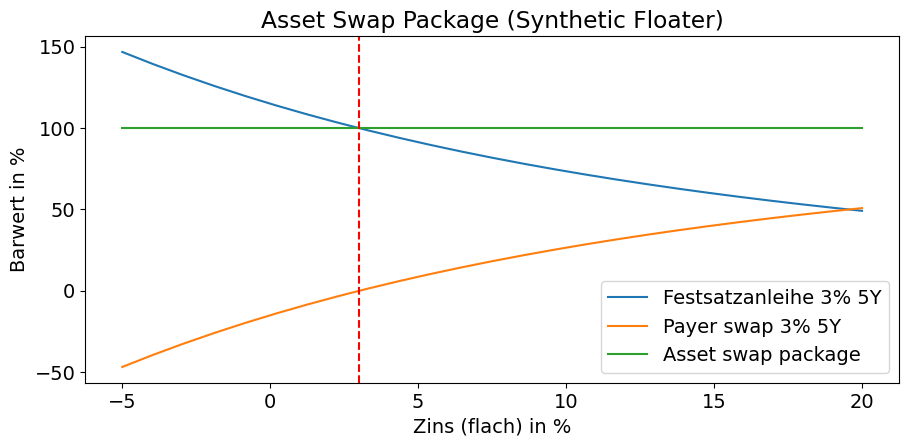

In [63]:
plot_synthetic_floater()

## Forward swap pricing

Swap von $s$ bis $T$ (erste Zahlung in $s+1$)

$$C_s = \frac{B_s - B_T}{\sum_{t=s+1}^T B_t}$$

In [64]:
def C_fwdswap(discount_factors, s=0):
    discount_factors = [1] + discount_factors  # B_0 = 1!
    return (discount_factors[s] - discount_factors[-1]) / sum(discount_factors[(s+1)::])

# this is the example from your ppt Slide 157
print(f'C_fwdswap in 0 for 3 = {C_fwdswap(discount_factors)*100 :.2f}%')
print(f'C_fwdswap in 1 for 2 = {C_fwdswap(discount_factors, 1)*100 :.2f}%')

C_fwdswap in 0 for 3 = 11.85%
C_fwdswap in 1 for 2 = 12.95%


## Delta vector

DV01 für verschiedene Laufzeiten in der Zinsstrukturkurve.

In [65]:
def delta_vector(swap_rates, s=0, nominal=100e+6):
    C_market = C_fwdswap(bootstrap(swap_rates), s)
    shifted = np.array([swap_rates, ]*len(swap_rates))
    shifted = shifted + np.eye(len(swap_rates)) * 0.0001
    deltas = []
    for rates in shifted:
        delta_t = MTM_receiver(bootstrap(rates), C_market, s)
        delta_t = round(delta_t, 5) * nominal
        deltas.extend([delta_t])
    return deltas

In [66]:
import warnings

def show_delta_vector():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)  # Ignore FutureWarnings

        dv_columns = [f'{t}Y' for t in range(1,len(swap_rates)+1)]
        dv_index = ['8Y', '1Y7Y', '3Y5Y']

        df = pd.DataFrame([delta_vector(swap_rates, 0), 
                        delta_vector(swap_rates, 1), 
                        delta_vector(swap_rates, 3)], index=dv_index, columns=dv_columns)
        df = df.round(2)
        df['Total'] = df.sum(axis=1)
        df[np.abs(df) == 0] = ''
        return df

In [67]:
# 1Y bis 8Y Swap Rates
swap_rates = np.array([0.0164, 0.0156, 0.0167, 0.0185, 0.0205, 0.0223, 0.0238, 0.025])
show_delta_vector()

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,Total
8Y,,,,,,,,-73000.0,-73000.0
1Y7Y,10000.0,,,,,,,-73000.0,-63000.0
3Y5Y,,,29000.0,,,,,-73000.0,-44000.0


## Forward Rate Agreement

- Gehandelter Geldmarktzinssatz in der Zukunft
- Nominalbetrag
- Ausgleichszahlung am Ende der Vorlaufperiode (!)
- Abrechnung gegen Referenzsatz (Euribor bzw. Libor)
- Käufer (Verkäufer) sichert sich gegen steigende (fallende) Zinsen ab
- 3X9 bedeutet Vorlauf drei Monate, Absicherung 6 Monate


Beispiel: Auf dem €-Geldmarkt wird ein Zinssatz von 7,00 % und ein Halbjahreszinssatz (183 Tage) von 6,50 % quotiert. Hieraus lässt sich der implizite Forwardsatz für ein halbes Jahr in einem halben Jahr errechnen:

![image.png](figures/forwardexample.png)

In [68]:
forward_rate = ( (1 + 0.07 * 365/360) / (1 + 0.065 * 183/360) - 1 ) * 360 / 182
print(f'Forward Rate (FRA Satz) = {forward_rate*100:.2f}%')

Forward Rate (FRA Satz) = 7.26%


Der Ausgleichsbetrag bei Settlement des FRA's ist

$$\frac{\text{Nominal} \times (\text{LIBOR} - \text{FRA Satz}) \frac{\text{FRA Tage}}{360} }{ 1+ \text{LIBOR} \frac{\text{FRA Tage}}{360}}$$

Beispiel: 6X12, 10 Mio. Nominal, FRA-Satz 7,26 %, Libor am Ende 8 %



![image.png](figures/schema-forward-rate-agreement-FRA-en.png)

In [69]:
settlement_payment = (10000000 * (0.08 - 0.0726)*182/360) / (1 + 0.08 * 182/360)
print(f'Ausgleichszahlung in d3 = {settlement_payment:.2f} EUR')

Ausgleichszahlung in d3 = 35956.86 EUR


## Cap / Floor

Der Käufer
- besitzt ein Bündel
- von europäischen Optionen (Caplets / Floorlets)
- deren Strike am Anfang jeder Euribor Periode
- mit dem Marktsatz verglichen wird.
- Ist die Option werthaltig, 
- erhält der Käufer die Zinsdifferenz 
- am Ende der Euribor Periode.  

Zins Cap, Beispiel:

- 5 Jahre gegen 6M EURIBOR
- Strike 5%
- Insgesamt 10 Caplets


[comment]: ![image.png](figures/cap2.png)

In [70]:
# Set the seed for reproducibility
np.random.seed(422)

# Generate the random process values with the correct standard deviation of 0.05
random_process = np.random.normal(0.05, 0.05, 8) * 100  # Standard deviation correctly set as 0.05

def plot_capfloor(is_cap=True):
    # Prepare the plot
    plt.figure()
    plt.plot(np.arange(6, 54, 6), random_process)
    
    # Adding a label "Hello" to grey scatter dots
    if is_cap:
        plt.title('Interest Rate Cap')
        # Plot the strike
        plt.axhline(y=5, color='r', linestyle='--', label='Strike (5%)')
        # Plot the rates
        first_label = True  # Helper to add the label only once
        for i, value in enumerate(random_process):
            if value > 5:
                if first_label:
                    plt.scatter(np.arange(6, 54, 6)[i], 5, color='red', s=100, marker='v', label='Hedged rate')
                    plt.scatter(np.arange(6, 54, 6)[i], value, color='grey', s=100, marker='o', label='Market rate')
                    first_label = False
                else:
                    plt.scatter(np.arange(6, 54, 6)[i], 5, color='red', s=100, marker='v')
                    plt.scatter(np.arange(6, 54, 6)[i], value, color='grey', s=100, marker='o')
    else:
        plt.title('Interest Rate Floor')
        # Plot the strike
        plt.axhline(y=3, color='r', linestyle='--', label='Strike (5%)')
        # Plot the rates
        first_label = True  # Helper to add the label only once
        for i, value in enumerate(random_process):
            if value < 3:
                if first_label:
                    plt.scatter(np.arange(6, 54, 6)[i], 3, color='red', s=100, marker='^', label='Hedged rate')
                    plt.scatter(np.arange(6, 54, 6)[i], value, color='grey', s=100, marker='o', label='Market rate')
                    first_label = False
                else:
                    plt.scatter(np.arange(6, 54, 6)[i], 3, color='red', s=100, marker='^')
                    plt.scatter(np.arange(6, 54, 6)[i], value, color='grey', s=100, marker='o')

    # Add labels and title
    plt.xlabel('Time in Months')
    plt.ylabel('Interest Rate (%)')
    plt.xticks(np.arange(6, 54, 6))
    plt.legend()

    # Display the plot
    plt.show()



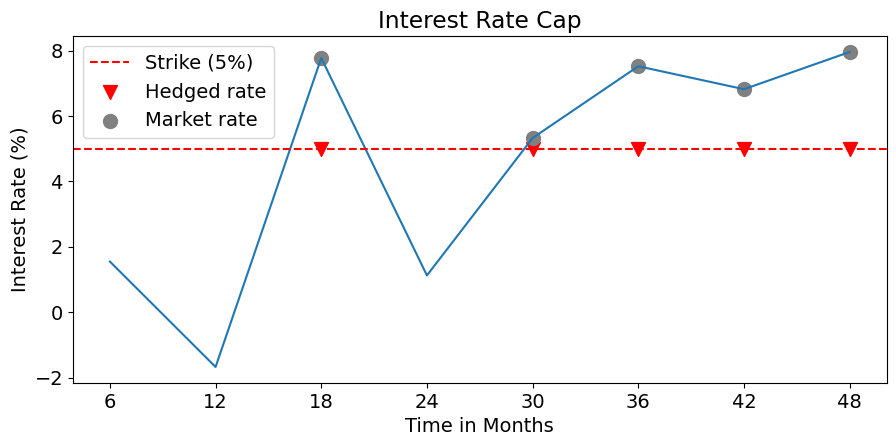

In [71]:
plot_capfloor(is_cap=True)

Zins Floor, Beispiel:

- 5 Jahre gegen 6M EURIBOR
- Strike 3%
- Insgesamt 10 Floorlets


[comment]: ![image.png](figures/floor2.png)

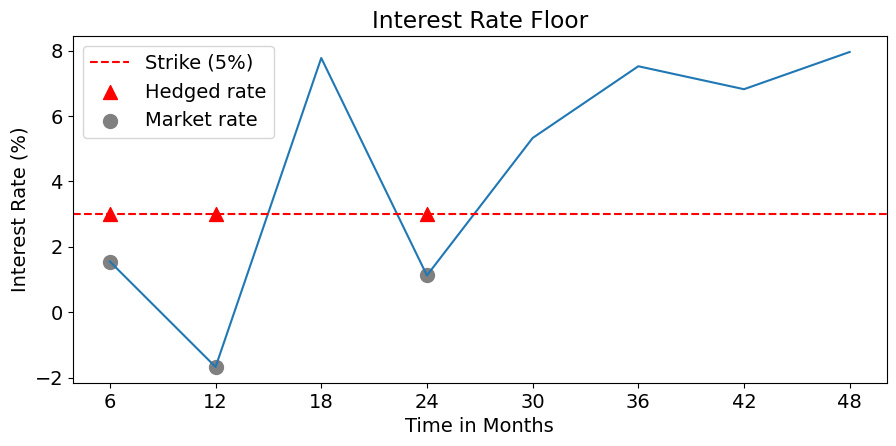

In [72]:
plot_capfloor(is_cap=False)

Cap / Floor Bewertung via Black76 (forward)

$$PV(Caplet) = \left[r_{forward} N(d_+)− K N(d_-)\right] e^{-rT} Z$$

$$PV(Floorlet) = \left[K N(-d_-) − r_{forward} N(-d_+) \right] e^{-rT} Z$$

mit

$$d_\pm = \frac{\ln\left(\frac{F_T}{K}\right) \pm \sigma^2 \frac{T}{2}}{\sigma \sqrt{T}}$$

und

$$Z = \frac{\text{Nominal} \frac{\text{Tage in cap periode}}{360} }{ 1 + r_{forward} \frac{\text{Tage in cap periode}}{360} }$$


Der Preis des Cap (Floor) ist einfach die Summe der Caplet (Floorlet) PVs.

![image.png](figures/swapfish.png)

<a id='Währungsmanagement'></a>

# Währungsmanagement und FX Derivate

Wie entstehen FX Risiken?

Welche Werkzeuge haben wir für das Risikomanagement?

## FX Quotierung (Spot)

Mengennotierung (!): Quotierung in Base/Quoted => Für eine Einheit Basis-Währung erhalte ich X Einheiten Quotierte-Währung, z.B.

- EURUSD = 1,0500 => 1,05 USD für einen EUR (Für einen Euro zahle ich 1,05 USD)
- GDPUSD = 1,6000 => 1,6000 USD für ein Pfund

Preisnotierung:

- Für einen USD zahle ich 1 / 1,05 = 0.9524 EUR

Quotierungs Hierarchie

![image.png](figures/currencyhirachy.png)

**Nicht konvertierbare Devisen** unterliegen einer Devisenbewirtschaftung. Der Umtausch in andere Währungen ist verboten oder nur mit Einzelgenehmigung möglich.

Nichtkonvertierbarkeit: China CNY, Brasilien BRL, Taiwan TWD, Argentinien ARS, Indonesien IDR

- Devisenerwerb, -besitz und -transfer untersagt
- Devisenlenkung
- Inlandswährung = reine Binnenwährung

Beschränkte Konvertibilität: Indien INR, Thailand THB, Kuwait KWD

- Austauschbarkeit begrenzt, Devisenbewirtschaftung
- Ausländerkonvertibilität
- Inländerkonvertibilität

Hieraus ergeben sich besondere Anforderungen an den Devisenhandel, e.g. Non-Deliverable Forward (NDF)

Cross Rates: Wechsel durch eine dritte Währung

![image.png](figures/crossrates.png)

In [73]:
# Beispiele:
EURUSD = 0.84226 * 1.6136  # EUR in GBP in USD
EURGBP = 1.3591  / 1.6136  # EUR in USD in GBP (Beachte die Richtung!)
print(f'EURUSD Cross Rate = {EURUSD:.4f}')
print(f'EURGBP Cross Rate = {EURGBP:.4f}')

EURUSD Cross Rate = 1.3591
EURGBP Cross Rate = 0.8423


## FX Termingeschäft

**Forward (Outright)**: Feste Vereinbarung zwischen zwei Kontrahenten über den Tausch von zwei fixierten Währungen zu einem bereits feststehenden Wechselkurs mit einem späteren Datum als die Valuta eines Kassageschäftes.

Arbitragebedingung ("Zinsparität"): Die Anlage in der Heimatwährung muss genauso ertragreich sein, wie die termingesicherte Anlage in der Fremdwährung.

$$\text{EURUSD} \times \left(1 + r_{USD} \frac{act}{360}\right) = \left(1 + r_{EUR} \frac{act}{360}\right) \times \text{Fwd EURUSD}$$


$$\text{Fwd EURUSD} = \text{EURUSD} \times \frac{1 + r_{USD} \frac{act}{360} }{ 1 + r_{EUR} \frac{act}{360} }$$

Vorsicht, $\frac{act}{360}$ gilt nicht in allen Währungen.

In [74]:
r_EUR, r_USD = [0.04, 0.02]
EURUSD_forward = 1.05 * ((1 + r_USD*365/360) / (1 + r_EUR*365/360))
print(f'Forward = {EURUSD_forward:.4f} EURUSD')

Forward = 1.0295 EURUSD


**Devisenswap**: Feste Vereinbarung zwischen zwei Kontrahenten über eine **FX-Kassatransaktion** UND ein gegenläufiges **FX-Terrmingeschäft (Outright)** über denselben Betrag (evtl. inkl. Zinsen) in dem gehandelten Währungspaar. Beide Transaktionen im Devisenswap werden simultan mit demselben Partner abgeschlossen.

Quotiert werden FX-Swaps in Swap- oder Forwardpunkten, die nichts anderes als die Zinsdifferenz zwischen zwischen Spot und Termingesachäft ausdrücken, und zwar in Kassapips.

$$\text{Swappunkte} = \text{FX Forward}  - \text{FX Spot} $$

Theorie vs Realität

![image.png](figures/forwardreal.png)

Non-Delivery-Forward (NDF):

Ein Terminkontrakt im OTC Markt, bei dem keine physische Abwicklung der beteiligten Währungen erfolgt, sondern der Terminkurs bei Verfall mit einem vorab fixiertem Fixingkurs  verglichen wird und bezogen auf den Nominalbetrag ein **Cash settlement in einer Hartwährung (meist USD)** Valuta 2 tägig erfolgt.

* In der Regel Einsatz bei EM (Emerging Markets) Währungen mit beschränkter Konvertibilität oder Nicht-Konvertierbarkeit im südamerikanischen, asiatischen und afrikanischem Raum
* Off-shore Markt mit höchster Liquidität in CNY, INR, KRW, BRL, CLP
* Auch handelbar bei frei konvertierbaren Währungen

## Devisenoptionen

Eine Devisenoption gibt dem Käufer das Recht
- eine Währung (Underlying) $S$
- zu einem festgesetzten Preis (Strike) $S_T$
- zu einem Zeitpunkt (european style) $T$
- zu kaufen (Euro Call) $= max(S_T - K, 0) = (S_T - K)^+$ oder 
- zu verkaufen (Euro Put) $= max(K - S_T, 0) = (K - S_T)^+$.


Euro Call = USD Put
Euro Put = USD Call   

![image.png](figures/optionpayout2.png)

Anwendung:

* Extremwert-Versicherungen
* Absicherung von bestandsbedrohenden Bewegungen
* Strike = Schmerzgrenze
* Ökonomische Absicherung ohne Liquiditätsrisiko aber Verlust des Zeitwertes


Bewertung durch Optionsmodell mit Zinsunterschieden (Garman Kohlhagen) oder Black76 (Forward)

$$PV(Call) = \left[F_T N(d_+)− K N(d_-)\right] e^{-rT}$$

$$PV(Put) = \left[K N(-d_-) − F_T N(-d_+) \right] e^{-rT}$$

mit

$$d_\pm = \frac{\ln\left(\frac{F_T}{K}\right) \pm \sigma^2 \frac{T}{2}}{\sigma \sqrt{T}}$$




![image.png](figures/callpreiseinfluss.png)

## Exkurs: Cross Currency Swap

Ein Währungsswap ist ein Vertrag zwischen zwei Parteien über den Austausch von unterschiedlichen, spezifizierten Zinszahlungen in verschiedenen Währungen innerhalb eines im Vertrag fixierten Zeitraumes.

Der Notional Amount wird beim Währungsswap i.d.R. ausgetauscht. Für alle Währungstransaktionen wird bei Geschäftsabschluß ein Devisenkurs fixiert.

In der Regel läßt sich ein Cross-Currency-Swap in drei Transaktionen gliedern: Anfangstransaktion / Zinstransaktion / Schlußtransaktion

Currency-Swaps sind eng verwandt mit den Devisenswaps, bei denen jedoch nur der Kapitaltausch erfolgt und nicht der zusätzliche Tausch von Zinsen in den zwei Währungen.
Currency- und Cross-Currency-Swaps werden unter anderem eingesetzt um Zins- und Währungsrisiken abzusichern Kostenvorteile, die durch unterschiedliche Spreads in zwei verschiedenen Kapitalmärkten auftreten, zu nutzen.

In [ ]:
# Export slides
from pathlib import Path
import subprocess
import sys

local_dir = Path.cwd()
subprocess.run([
    sys.executable, "-m", "jupyter", "nbconvert", str(local_dir / "vdt.ipynb"),
    "--to", "slides", "--SlidesExporter.reveal_scroll=True",
], check=True)

In [ ]:
# Generate PDF without the default mathrsfs dependency
from pathlib import Path
import os
import subprocess
import sys

local_dir = Path.cwd()
env = os.environ.copy()
env["TEXMFVAR"] = "/tmp/texmf-var"

subprocess.run([
    sys.executable, "-m", "jupyter", "nbconvert", str(local_dir / "vdt.ipynb"),
    "--to", "latex", "--output", "vdt",
], check=True, env=env)

tex_path = local_dir / "vdt.tex"
tex_path.write_text(
    tex_path.read_text(encoding="utf-8").replace("\\usepackage{mathrsfs}\n", ""),
    encoding="utf-8",
)

for _ in range(3):
    subprocess.run([
        "xelatex", "-interaction=nonstopmode", tex_path.name,
    ], check=True, cwd=local_dir, env=env)